In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv('/content/online_retail_clean.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,revenue
0,568375,BANK CHARGES,Bank Charges,1.0,2011-09-26 17:01:00 UTC,0.001,13405.0,United Kingdom,0.001
1,496222,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-01-29 13:53:00 UTC,0.001,13583.0,United Kingdom,0.001
2,533528,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-11-17 15:08:00 UTC,0.001,15750.0,United Kingdom,0.001
3,501176,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-03-15 11:00:00 UTC,0.001,14857.0,United Kingdom,0.001
4,522766,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-09-16 13:58:00 UTC,0.001,15182.0,United Kingdom,0.001


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256240 entries, 0 to 256239
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      256240 non-null  int64  
 1   StockCode    256240 non-null  object 
 2   Description  256240 non-null  object 
 3   Quantity     256239 non-null  float64
 4   InvoiceDate  256239 non-null  object 
 5   Price        256239 non-null  float64
 6   Customer_ID  256239 non-null  float64
 7   Country      256239 non-null  object 
 8   revenue      256239 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 17.6+ MB


,Invoice,Quantity,Price,Customer_ID,revenue
count,256240.000000,256239.000000,256239.000000,256239.000000,256239.000000
mean,538581.528243,2.771206,1.821440,15728.337767,3.089698
std,27006.921756,3.957748,1.299831,1599.364276,1.593173
min,489442.000000,1.000000,0.001000,12346.000000,0.001000
25%,516330.000000,1.000000,0.850000,14527.000000,1.660000
50%,537155.000000,2.000000,1.490000,15862.000000,2.950000
75%,563555.000000,3.000000,2.550000,17156.500000,4.250000
max,581585.000000,100.000000,6.000000,18287.000000,6.240000


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256240 entries, 0 to 256239
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   Invoice      256240 non-null  int64              
 1   StockCode    256240 non-null  object             
 2   Description  256240 non-null  object             
 3   Quantity     256239 non-null  float64            
 4   InvoiceDate  256239 non-null  datetime64[ns, UTC]
 5   Price        256239 non-null  float64            
 6   Customer_ID  256239 non-null  float64            
 7   Country      256239 non-null  object             
 8   revenue      256239 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(4), int64(1), object(3)
memory usage: 17.6+ MB


In [ ]:
# Remove cancelled or invalid transactions
df = df[df['Quantity'] > 0]

# Remove missing customer IDs
df = df[df['Customer_ID'].notna()]

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,revenue,Revenue
0,568375,BANK CHARGES,Bank Charges,1.0,2011-09-26 17:01:00+00:00,0.001,13405.0,United Kingdom,0.001,0.001
1,496222,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-01-29 13:53:00+00:00,0.001,13583.0,United Kingdom,0.001,0.001
2,533528,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-11-17 15:08:00+00:00,0.001,15750.0,United Kingdom,0.001,0.001
3,501176,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-03-15 11:00:00+00:00,0.001,14857.0,United Kingdom,0.001,0.001
4,522766,PADS,PADS TO MATCH ALL CUSHIONS,1.0,2010-09-16 13:58:00+00:00,0.001,15182.0,United Kingdom,0.001,0.001


In [ ]:
df.describe()
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer_ID,0
Country,0
revenue,0
Revenue,0


In [ ]:
customer_df = df.groupby('Customer_ID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    Total_Quantity=('Quantity', 'sum'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

customer_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase
0,12346.0,28.05,2,6.0,2009-12-18 10:55:00+00:00,2010-03-02 13:08:00+00:00
1,12347.0,11.04,2,36.0,2011-01-26 14:30:00+00:00,2011-04-07 10:43:00+00:00
2,12348.0,1.00,1,1.0,2010-09-27 14:59:00+00:00,2010-09-27 14:59:00+00:00
3,12353.0,10.08,1,24.0,2010-10-27 12:44:00+00:00,2010-10-27 12:44:00+00:00
4,12355.0,10.08,1,24.0,2010-05-21 11:59:00+00:00,2010-05-21 11:59:00+00:00


In [ ]:
customer_df.info()
customer_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3516 entries, 0 to 3515
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Customer_ID     3516 non-null   float64            
 1   Total_Revenue   3516 non-null   float64            
 2   Total_Orders    3516 non-null   int64              
 3   Total_Quantity  3516 non-null   float64            
 4   First_Purchase  3516 non-null   datetime64[ns, UTC]
 5   Last_Purchase   3516 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](2), float64(3), int64(1)
memory usage: 164.9 KB


,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity
count,3516.000000,3516.000000,3516.000000,3516.000000
mean,15445.015358,225.170986,4.201365,201.959898
std,1710.761153,705.511451,9.516616,531.833744
min,12346.000000,0.001000,1.000000,1.000000
25%,13988.750000,15.120000,1.000000,24.000000
50%,15526.500000,60.480000,2.000000,72.000000
75%,16955.250000,202.552500,4.000000,194.000000
max,18287.000000,25786.430000,273.000000,18317.000000


day 2

In [ ]:
customer_df = customer_df.sort_values(by='Total_Revenue', ascending=False)

customer_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase
3234,17841.0,25786.43,209,18317.0,2009-12-02 15:41:00+00:00,2011-12-08 12:07:00+00:00
218,12748.0,13608.57,273,11371.0,2009-12-04 17:31:00+00:00,2011-12-09 12:20:00+00:00
1240,14606.0,13033.60,182,7711.0,2009-12-03 12:40:00+00:00,2011-12-08 19:28:00+00:00
942,14096.0,8325.59,16,4042.0,2011-08-30 10:49:00+00:00,2011-12-05 17:17:00+00:00
1629,15311.0,7065.41,192,4490.0,2009-12-01 11:21:00+00:00,2011-12-09 12:00:00+00:00


Calculate Revenue Contribution Percentage

In [ ]:
total_revenue = customer_df['Total_Revenue'].sum()
total_revenue

np.float64(791701.188)

In [ ]:
customer_df['Revenue_Percentage'] = (
    customer_df['Total_Revenue'] / total_revenue
) * 100

customer_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Revenue_Percentage
3234,17841.0,25786.43,209,18317.0,2009-12-02 15:41:00+00:00,2011-12-08 12:07:00+00:00,3.257091
218,12748.0,13608.57,273,11371.0,2009-12-04 17:31:00+00:00,2011-12-09 12:20:00+00:00,1.718902
1240,14606.0,13033.60,182,7711.0,2009-12-03 12:40:00+00:00,2011-12-08 19:28:00+00:00,1.646278
942,14096.0,8325.59,16,4042.0,2011-08-30 10:49:00+00:00,2011-12-05 17:17:00+00:00,1.051608
1629,15311.0,7065.41,192,4490.0,2009-12-01 11:21:00+00:00,2011-12-09 12:00:00+00:00,0.892434


Cumulative Revenue (Pareto Analysis)

In [ ]:
customer_df['Cumulative_Revenue_Percentage'] = (
    customer_df['Revenue_Percentage'].cumsum()
)

customer_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Revenue_Percentage,Cumulative_Revenue_Percentage
3234,17841.0,25786.43,209,18317.0,2009-12-02 15:41:00+00:00,2011-12-08 12:07:00+00:00,3.257091,3.257091
218,12748.0,13608.57,273,11371.0,2009-12-04 17:31:00+00:00,2011-12-09 12:20:00+00:00,1.718902,4.975994
1240,14606.0,13033.60,182,7711.0,2009-12-03 12:40:00+00:00,2011-12-08 19:28:00+00:00,1.646278,6.622271
942,14096.0,8325.59,16,4042.0,2011-08-30 10:49:00+00:00,2011-12-05 17:17:00+00:00,1.051608,7.673879
1629,15311.0,7065.41,192,4490.0,2009-12-01 11:21:00+00:00,2011-12-09 12:00:00+00:00,0.892434,8.566313


Identify Top 20% Customers

In [ ]:
top_20_percent_count = int(0.2 * len(customer_df))
top_20_percent_count

703

In [ ]:
top_20_revenue_share = customer_df.head(top_20_percent_count)['Revenue_Percentage'].sum()

top_20_revenue_share

np.float64(77.82125508191103)

Visualize Revenue Distribution

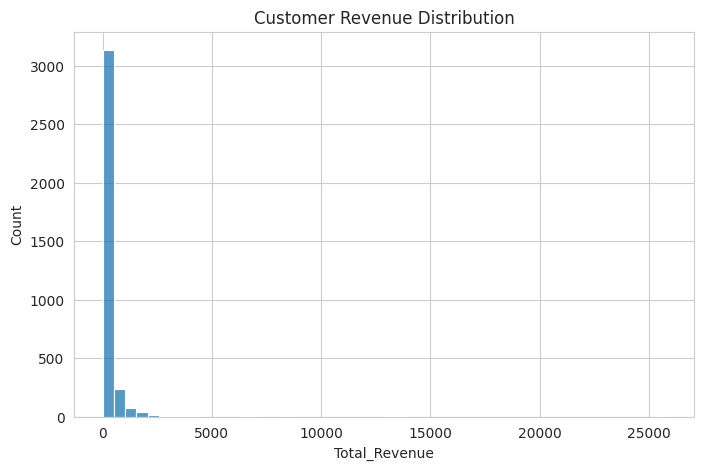

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df['Total_Revenue'], bins=50)
plt.title("Customer Revenue Distribution")
plt.show()

In [ ]:
top_20_percent_count = int(0.2 * len(customer_df))
top_20_revenue_share = customer_df.head(top_20_percent_count)['Revenue_Percentage'].sum()

top_20_revenue_share

np.float64(77.82125508191103)

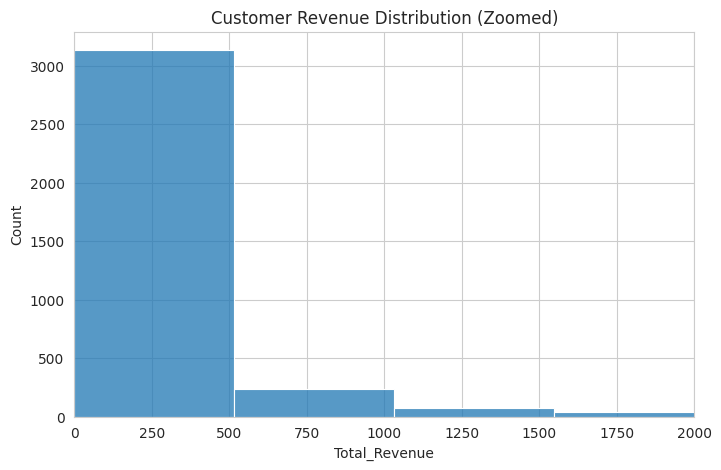

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df['Total_Revenue'], bins=50)
plt.xlim(0, 2000)
plt.title("Customer Revenue Distribution (Zoomed)")
plt.show()

Create Customer Segments (Rule-Based)

In [ ]:
def segment_customer(row):
    if row['Total_Revenue'] > 500:
        return "High Value"
    elif row['Total_Revenue'] > 100:
        return "Mid Value"
    else:
        return "Low Value"

customer_df['Customer_Segment'] = customer_df.apply(segment_customer, axis=1)

customer_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Revenue_Percentage,Cumulative_Revenue_Percentage,Customer_Segment
3234,17841.0,25786.43,209,18317.0,2009-12-02 15:41:00+00:00,2011-12-08 12:07:00+00:00,3.257091,3.257091,High Value
218,12748.0,13608.57,273,11371.0,2009-12-04 17:31:00+00:00,2011-12-09 12:20:00+00:00,1.718902,4.975994,High Value
1240,14606.0,13033.60,182,7711.0,2009-12-03 12:40:00+00:00,2011-12-08 19:28:00+00:00,1.646278,6.622271,High Value
942,14096.0,8325.59,16,4042.0,2011-08-30 10:49:00+00:00,2011-12-05 17:17:00+00:00,1.051608,7.673879,High Value
1629,15311.0,7065.41,192,4490.0,2009-12-01 11:21:00+00:00,2011-12-09 12:00:00+00:00,0.892434,8.566313,High Value


Segment Revenue Contribution

In [ ]:
segment_summary = customer_df.groupby('Customer_Segment').agg(
    Customers=('Customer_ID', 'count'),
    Total_Revenue=('Total_Revenue', 'sum')
).reset_index()

segment_summary

,Customer_Segment,Customers,Total_Revenue
0,High Value,401,505627.571
1,Low Value,2171,68045.645
2,Mid Value,944,218027.972


Segment Revenue Percentage

In [ ]:
segment_summary['Revenue_Percentage'] = (
    segment_summary['Total_Revenue'] / total_revenue
) * 100

segment_summary

,Customer_Segment,Customers,Total_Revenue,Revenue_Percentage
0,High Value,401,505627.571,63.865961
1,Low Value,2171,68045.645,8.594865
2,Mid Value,944,218027.972,27.539175


segmentation logic using quartiles

Revenue Quartiles

In [ ]:
customer_df['Total_Revenue'].describe()

,Total_Revenue
count,3516.000000
mean,225.170986
std,705.511451
min,0.001000
25%,15.120000
50%,60.480000
75%,202.552500
max,25786.430000


Create Quartile-Based Segmentation

In [ ]:
customer_df['Revenue_Segment'] = pd.qcut(
    customer_df['Total_Revenue'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'Top Value']
)

In [ ]:
customer_df['Revenue_Segment'].value_counts()

,count
Revenue_Segment,
Low Value,922
Top Value,879
High Value,878
Mid Value,837


Segment Revenue Summary

In [ ]:
segment_summary = customer_df.groupby('Revenue_Segment').agg(
    Customers=('Customer_ID', 'count'),
    Total_Revenue=('Total_Revenue', 'sum')
).reset_index()

segment_summary['Revenue_Percentage'] = (
    segment_summary['Total_Revenue'] / total_revenue
) * 100

segment_summary

/tmp/ipython-input-1656975872.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = customer_df.groupby('Revenue_Segment').agg(


,Revenue_Segment,Customers,Total_Revenue,Revenue_Percentage
0,Low Value,922,6974.759,0.880984
1,Mid Value,837,28889.696,3.649066
2,High Value,878,98238.822,12.408573
3,Top Value,879,657597.911,83.061377


Pareto Curve (Cumulative Revenue %)

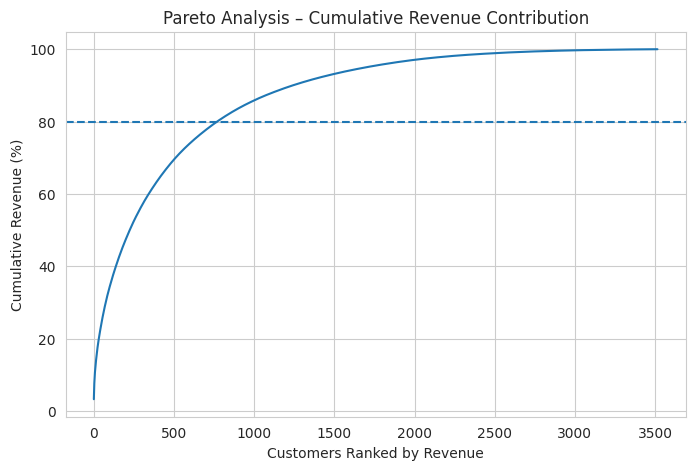

In [ ]:
customer_df_sorted = customer_df.sort_values(by='Total_Revenue', ascending=False)
customer_df_sorted['Cumulative_Revenue'] = customer_df_sorted['Total_Revenue'].cumsum()
customer_df_sorted['Cumulative_Percentage'] = (
    customer_df_sorted['Cumulative_Revenue'] / total_revenue
) * 100

plt.figure(figsize=(8,5))
plt.plot(customer_df_sorted['Cumulative_Percentage'].values)
plt.axhline(80, linestyle='--')
plt.title("Pareto Analysis – Cumulative Revenue Contribution")
plt.ylabel("Cumulative Revenue (%)")
plt.xlabel("Customers Ranked by Revenue")
plt.show()

day 3


Revenue by Segment

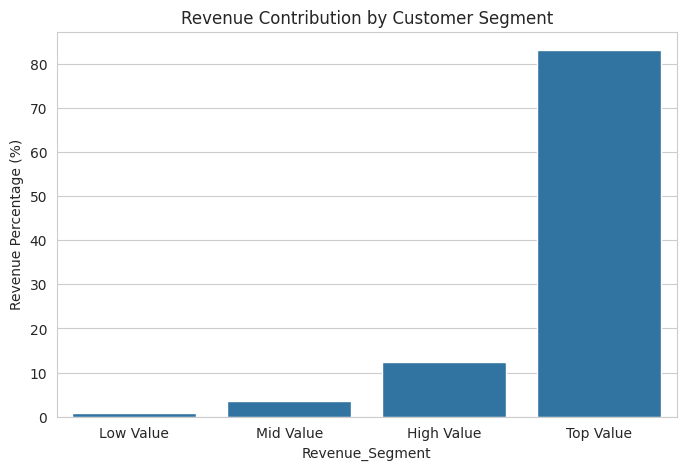

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=segment_summary, x='Revenue_Segment', y='Revenue_Percentage')
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Revenue Percentage (%)")
plt.show()

Key Findings

Revenue distribution is heavily right-skewed.

Top 20% customers generate 77.8% of total revenue.

The top quartile (Top Value segment) contributes disproportionately to total sales.

Revenue concentration indicates strong dependency on high-value customers.

Business Implications

Retention strategies should prioritize Top Value customers.

Loyalty incentives can increase lifetime value.

Mid-tier customers represent growth opportuni

RFM Segmentation (Industry Standard)

In [ ]:
analysis_date = df['InvoiceDate'].max()

customer_df['Recency_Days'] = (
    analysis_date - customer_df['Last_Purchase']
).dt.days

customer_df.head()

,Customer_ID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Revenue_Percentage,Cumulative_Revenue_Percentage,Customer_Segment,Revenue_Segment,Recency_Days
3234,17841.0,25786.43,209,18317.0,2009-12-02 15:41:00+00:00,2011-12-08 12:07:00+00:00,3.257091,3.257091,High Value,Top Value,1
218,12748.0,13608.57,273,11371.0,2009-12-04 17:31:00+00:00,2011-12-09 12:20:00+00:00,1.718902,4.975994,High Value,Top Value,0
1240,14606.0,13033.60,182,7711.0,2009-12-03 12:40:00+00:00,2011-12-08 19:28:00+00:00,1.646278,6.622271,High Value,Top Value,0
942,14096.0,8325.59,16,4042.0,2011-08-30 10:49:00+00:00,2011-12-05 17:17:00+00:00,1.051608,7.673879,High Value,Top Value,3
1629,15311.0,7065.41,192,4490.0,2009-12-01 11:21:00+00:00,2011-12-09 12:00:00+00:00,0.892434,8.566313,High Value,Top Value,0


RFM Scoring (Quartile-Based)

Create Analysis Date & Recency

In [ ]:
# Reference date (latest transaction date)
analysis_date = df['InvoiceDate'].max()

# Calculate Recency (days since last purchase)
customer_df['Recency_Days'] = (
    analysis_date - customer_df['Last_Purchase']
).dt.days

Create RFM Scores (Handling Duplicates Properly)

In [ ]:
import pandas as pd

# Recency Score (Lower Recency = Better → reverse labels)
customer_df['R_Score'] = pd.qcut(
    customer_df['Recency_Days'],
    4,
    labels=[4,3,2,1]
)

# Frequency Score (Handle duplicate edges issue)
customer_df['F_Score'] = pd.qcut(
    customer_df['Total_Orders'].rank(method='first'), # Fixed: Using .rank(method='first')
    4,
    labels=[1,2,3,4]
)

# Monetary Score
customer_df['M_Score'] = pd.qcut(
    customer_df['Total_Revenue'],
    4,
    labels=[1,2,3,4]
)

Combine into RFM Score

In [ ]:
customer_df['RFM_Score'] = (
    customer_df['R_Score'].astype(str) +
    customer_df['F_Score'].astype(str) +
    customer_df['M_Score'].astype(str)
)

customer_df[['Customer_ID','Recency_Days','Total_Orders','Total_Revenue','RFM_Score']].head()

,Customer_ID,Recency_Days,Total_Orders,Total_Revenue,RFM_Score
3234,17841.0,1,209,25786.43,444
218,12748.0,0,273,13608.57,444
1240,14606.0,0,182,13033.60,444
942,14096.0,3,16,8325.59,444
1629,15311.0,0,192,7065.41,444


Create Business-Friendly RFM Segments

In [ ]:
def rfm_segment(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['M_Score'] == 4:
        return 'High Value'

    elif int(row['F_Score']) >= 3:
        return 'Loyal Customers'

    elif int(row['R_Score']) == 4:
        return 'Recent Customers'

    else:
        return 'Standard Customers'

customer_df['RFM_Segment'] = customer_df.apply(rfm_segment, axis=1)

RFM Summary Table

In [ ]:
rfm_summary = customer_df.groupby('RFM_Segment').agg(
    Customers=('Customer_ID','count'),
    Total_Revenue=('Total_Revenue','sum')
).reset_index()

# Calculate revenue percentage
rfm_summary['Revenue_Percentage'] = (
    rfm_summary['Total_Revenue'] / total_revenue
) * 100

rfm_summary.sort_values(by='Revenue_Percentage', ascending=False)

,RFM_Segment,Customers,Total_Revenue,Revenue_Percentage
0,Champions,341,398930.951,50.389081
1,High Value,538,258666.960,32.672297
2,Loyal Customers,977,63950.229,8.077571
4,Standard Customers,1456,59074.718,7.461744
3,Recent Customers,204,11078.330,1.399307


Visualize RFM Revenue Contribution

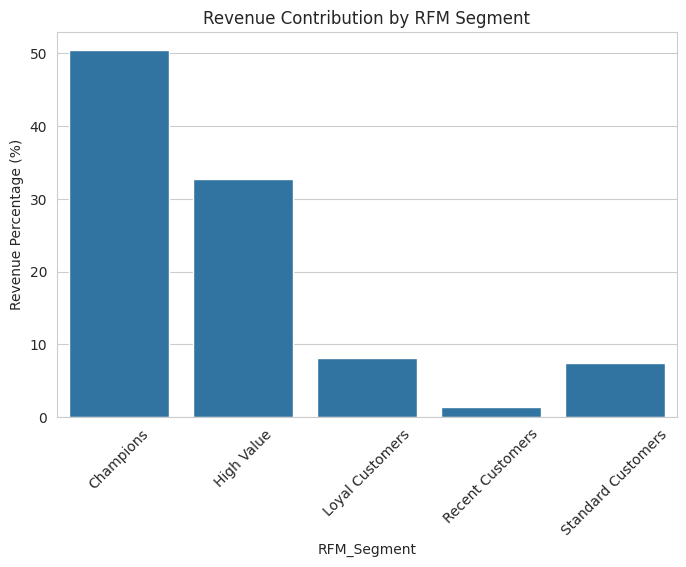

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=rfm_summary, x='RFM_Segment', y='Revenue_Percentage')
plt.title("Revenue Contribution by RFM Segment")
plt.ylabel("Revenue Percentage (%)")
plt.xticks(rotation=45)
plt.show()